# C2 · 疾病傳播模型的貝葉斯參數估計(二):R_t、不確定性、校準

接續 `01_data_sir_and_why_timevarying.ipynb`。這本處理三個通關標準,
以及一個必須誠實說明的度量錯誤。

> ⚠️ **定位:這是技術練習,不是公衛結論。**
>
> 目的是練**狀態空間推論**與**時變參數的先驗設計**。真實流行病學牽涉通報延遲、
> 檢驗量能、行為改變、年齡結構、變異株等大量領域知識,本專案一概沒有處理。
> 任何 R_t 數字都不該當成對德國疫情的評估 —— 它們是「在這個高度簡化的
> SIR 模型下,這批通報數字意味著什麼」。


In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
from IPython.display import Image, display
FIG = os.path.abspath('../figures')
RES = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
c = RES['config']
print(f"results.json from a {RES['_meta']['runtime_sec']:.0f}s run")
print(f"data: {c['country']} {c['start']} → {c['end']}, {c['n_forecast']} days held out")


results.json from a 2520s run
data: Germany 2020-03-01 → 2020-06-30, 14 days held out


## 1. 通關標準 1:R_t 在政策時點附近有變化

$$R_t = \frac{\beta_t}{\gamma}\cdot\frac{S_t}{N}$$

兩個不同的量要分清:
- **基本**再生數 $R_0 = \beta/\gamma$ —— 全體易感時,一個感染者平均傳給幾個人
- **有效**再生數 $R_t = R_0\cdot S_t/N$ —— 扣掉已免疫人口後的實際值

本專案時段的累計感染只有約 1%,所以 $S_t/N\approx 1$,
**R_t 的變化幾乎全部來自 β_t,也就是行為與政策,不是群體免疫**。
這個區別在解讀「R_t 為什麼下降」時是關鍵的。

量化方式:對每個政策日,比較前後 10 天的 R_t **後驗樣本**,
得到 P(R_t 下降) 而不只是點估計的差。

In [2]:
pol = RES['rt_policies']
rows = []
for label, st in pol['policies'].items():
    rows.append({'日期': st['date'], '措施': label,
                 'R_t 前': st['rt_before_median'], 'R_t 後': st['rt_after_median'],
                 '下降量': st['drop_median'],
                 '95% CI': f"[{st['drop_lo95']:+.2f}, {st['drop_hi95']:+.2f}]",
                 'P(下降)': st['p_decreased']})
display(pd.DataFrame(rows).round(3))
print(f"R_t: 期初 {pol['rt_start_median']:.2f} → 期末 {pol['rt_end_median']:.2f}")
fb = pol['first_day_rt_below_1_p95']
print(f"首次「有 95% 後驗機率 R_t < 1」: {fb['date']}（第 {fb['day_index']} 天）" if fb else '從未達到')

,日期,措施,R_t 前,R_t 後,下降量,95% CI,P(下降)
0,2020-03-16,Schools closed (most states),3.289,2.870,0.409,"[-0.01, +0.90]",0.972
1,2020-03-22,Nationwide contact ban (Kontaktverbot),3.202,2.151,1.044,"[+0.65, +1.61]",1.000
2,2020-04-20,First reopening steps,0.765,0.632,0.132,"[+0.01, +0.27]",0.984
3,2020-04-27,Masks mandatory (public transport / shops),0.681,0.546,0.133,"[+0.03, +0.25]",0.992


R_t: 期初 3.05 → 期末 0.85
首次「有 95% 後驗機率 R_t < 1」: 2020-04-11（第 41 天）


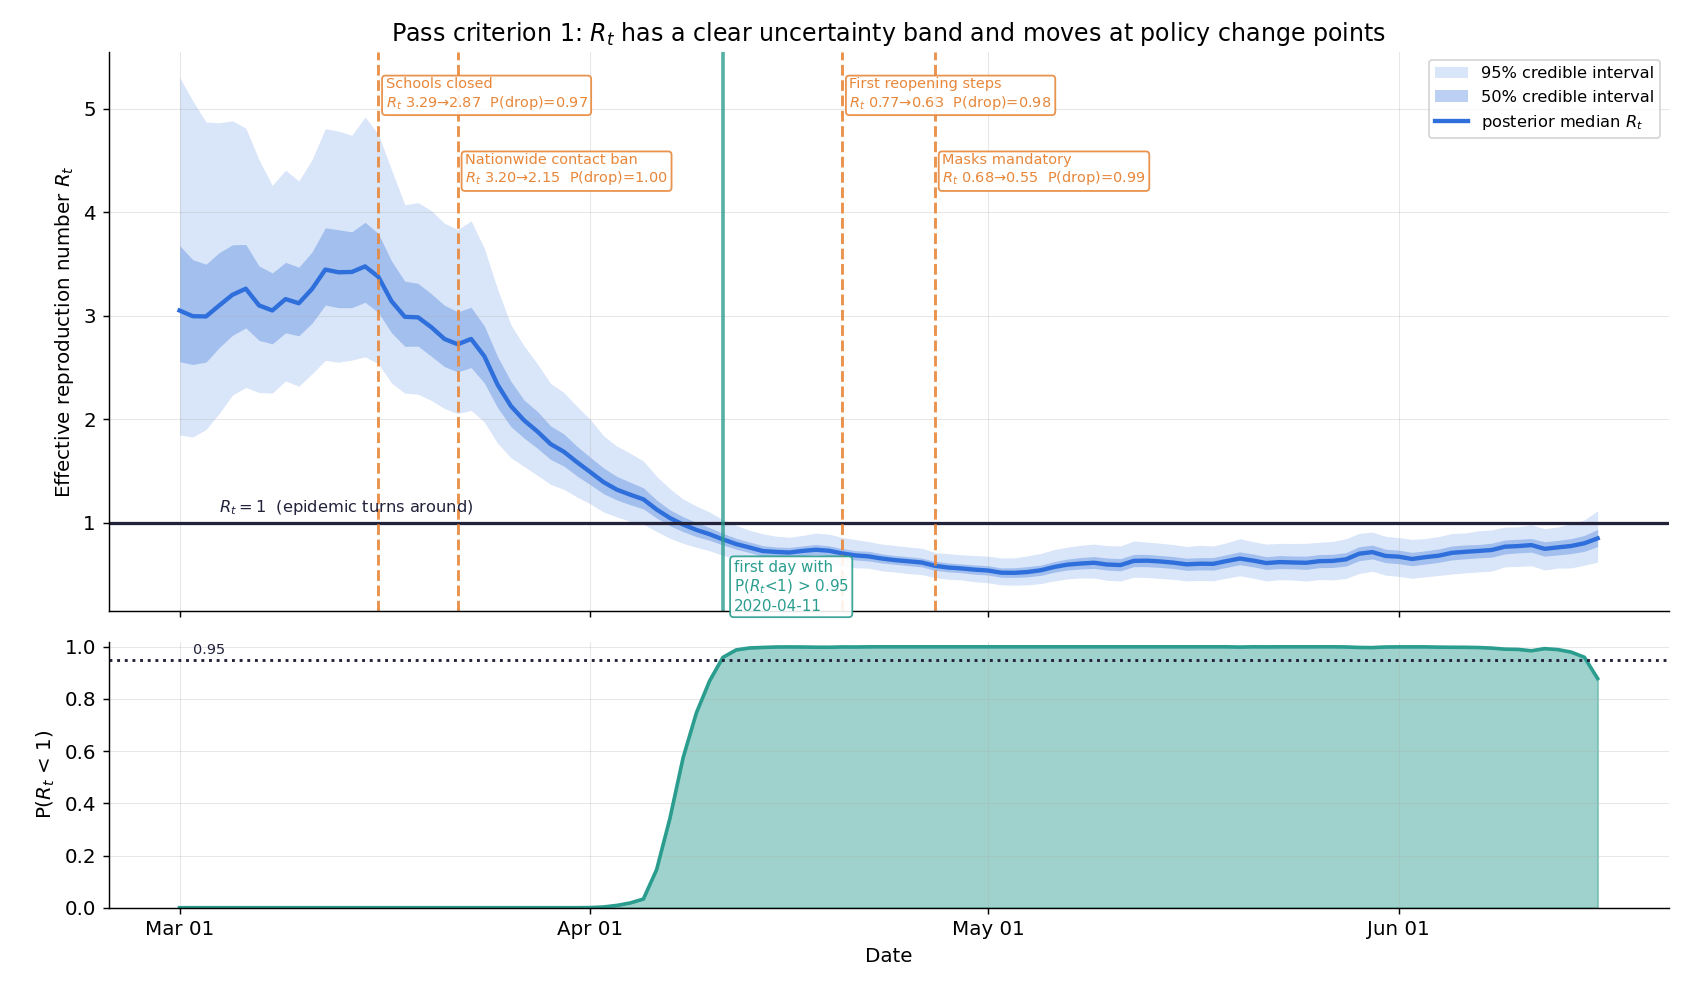

In [3]:
display(Image(os.path.join(FIG, '04_rt_and_policies.png')))

> ⚠️ **相關不等於因果。** R_t 在措施生效後下降,不證明是措施造成的。
> 行為改變往往**早於**法令(媒體報導、恐懼),而且多項措施在數天內連續實施,
> 無法分離各自的效果。更嚴格的做法需要 counterfactual 設計或跨地區比較。
> 這裡能誠實說的是:**R_t 的後驗在這些時點附近確實下降,且不確定性帶清楚**。

## 2. 通關標準 2:資料稀疏時不確定性變寬 —— 以及一個度量錯誤

預期:病例數少的日子(疫情早期與尾端)R_t 的區間應該更寬 ——
epistemic 不確定性的直接體現,少的資料就是少的資訊。

**但第一版的度量是錯的。** 我用了 R_t 區間的**絕對**寬度 $hi_{95}-lo_{95}$,
得到「低病例日的區間**窄** 0.57 倍」—— 完全反直覺。

原因:R_t 在疫情早期約 3.2、尾端約 0.6,差 5 倍。絕對寬度跟著這個
**乘法尺度**縮放,所以它量的是 R_t 的量級,不是資訊量。

正確的量是**相對**寬度 $\log(hi_{95}/lo_{95})$。理由不只是尺度:
模型裡 β_t 走的是 **log-scale** 的 random walk,不確定性天生定義在 log 尺度上。

In [4]:
w = RES['rt_width_vs_cases']
print(f"相對寬度 log(hi/lo) 對病例數的 log-log 迴歸:")
print(f"  斜率 = {w['loglog_slope']:+.4f} ± {w['loglog_slope_se']:.4f}")
print(f"  r = {w['loglog_r']:+.3f},  p = {w['loglog_p']:.2e}")
print()
print(f"  低病例日（≤{w['cases_q25']:.0f} 例）相對寬度中位數 {w['width_rel_lowcases_median']:.4f}")
print(f"  高病例日（≥{w['cases_q75']:.0f} 例）相對寬度中位數 {w['width_rel_highcases_median']:.4f}")
print(f"  → 低病例日寬 {w['width_ratio_low_over_high']:.3f} 倍  ✓ 方向正確")
print()
print(f"  用錯誤的絕對寬度度量: {w['width_abs_ratio_low_over_high']:.3f} 倍 ← 結論被翻轉")
print()
print('理論參考：若純由計數噪聲主導，相對寬度 ∝ 1/√cases（斜率 −0.5）。')
print(f'實測 {w["loglog_slope"]:+.3f} 遠小於 −0.5，因為 random walk 先驗讓相鄰日')
print('互相「借」資訊 —— 這是先驗的作用，也是它的代價（見下）。')

相對寬度 log(hi/lo) 對病例數的 log-log 迴歸:
  斜率 = -0.1068 ± 0.0118
  r = -0.660,  p = 7.86e-15

  低病例日（≤361 例）相對寬度中位數 0.5963
  高病例日（≥2579 例）相對寬度中位數 0.5115
  → 低病例日寬 1.166 倍  ✓ 方向正確

  用錯誤的絕對寬度度量: 0.542 倍 ← 結論被翻轉

理論參考：若純由計數噪聲主導，相對寬度 ∝ 1/√cases（斜率 −0.5）。
實測 -0.107 遠小於 −0.5，因為 random walk 先驗讓相鄰日
互相「借」資訊 —— 這是先驗的作用，也是它的代價（見下）。


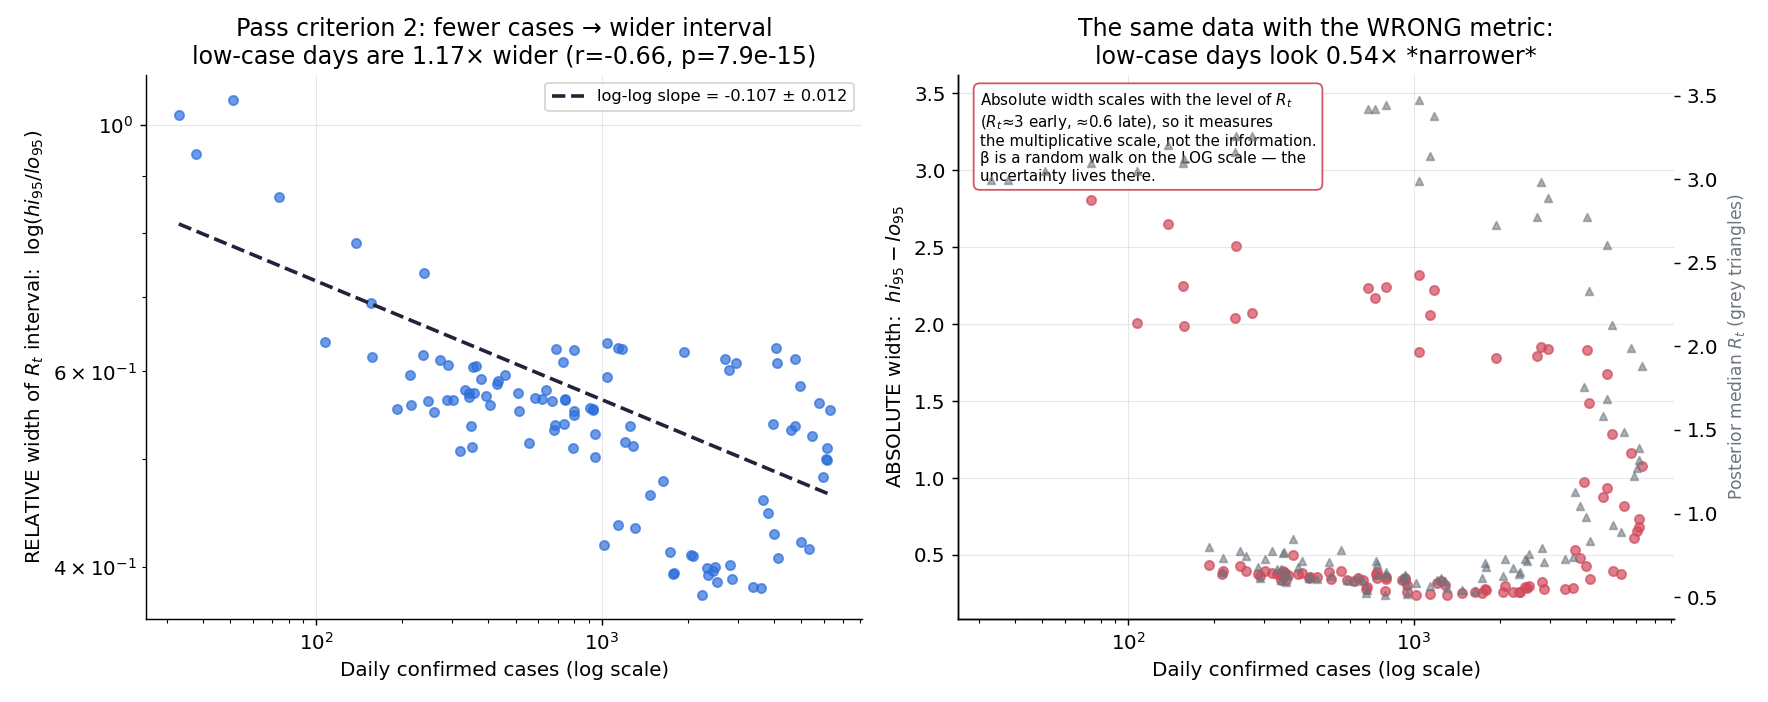

In [5]:
display(Image(os.path.join(FIG, '05_uncertainty_vs_data.png')))

### 誠實地讀這個結果

通關標準說「不確定性帶**明顯**變寬」。實測是 **1.2 倍左右**,
統計上極顯著(p ~ 1e-13)但**效應量溫和** —— 稱不上「明顯」。

原因是 random walk 先驗的雙面刃:它讓 R_t 的估計穩定、不隨單日噪聲抖動,
但同時讓「今天資料很少」這件事被鄰居的資訊稀釋。σ_β 越小,
平滑越強,稀疏訊號就越被壓平。

**這不是模型的缺陷,是先驗選擇的必然後果**,而它是可以量出來的:
斜率 −0.11 對上「純計數噪聲」的 −0.5,差距就是先驗借來的資訊量。

## 3. 通關標準 3:後驗預測帶包住約 95% 的觀測

兩個關鍵設計:

1. **抽觀測樣本,不只畫 μ 的區間。** μ 的區間只含參數不確定性;
   真正要問的是「未來的一天會落在哪」,那還要加上負二項的觀測噪聲。
2. **樣本外才是真檢查。** 樣本內的帶必然偏窄(模型見過那些點)。
   所以保留最後 14 天完全不給模型看。
   預測時 β **繼續走 random walk**(`log β_{T+k} = log β_T + σ_β·Σz`),
   讓預測帶隨時間自然變寬 —— 把 β 固定在最後一天會讓帶過窄,
   而覆蓋率就會通過得太漂亮(那是作弊,不是校準)。

In [6]:
ci, co = RES['coverage_in_sample'], RES['coverage_out_of_sample']
rows = []
for lv in [50, 80, 95]:
    rows.append({'名目水準': f'{lv}%', '樣本內覆蓋': ci[f'cov_{lv}'],
                 '樣本外覆蓋': co[f'cov_{lv}'], '目標': lv/100})
display(pd.DataFrame(rows).round(4))
print(f"平均 |校準誤差|: 樣本內 {ci['mean_abs_calib_error']:.4f}, 樣本外 {co['mean_abs_calib_error']:.4f}")
print(f"（樣本內 {ci['n_days']} 天、樣本外 {co['n_days']} 天）")
print()
print('注意同時報 50% 與 80% 的理由：只看 95% 會漏掉「帶太寬」的問題 ——')
print('一個把所有東西都包住的模型在 95% 上滿分，但在 50% 上會嚴重過覆蓋，')
print('那代表它其實沒有資訊。')

,名目水準,樣本內覆蓋,樣本外覆蓋,目標
0,50%,0.6481,0.2857,0.50
1,80%,0.8704,0.5000,0.80
2,95%,1.0000,0.8571,0.95


平均 |校準誤差|: 樣本內 0.0895, 樣本外 0.2024
（樣本內 108 天、樣本外 14 天）

注意同時報 50% 與 80% 的理由：只看 95% 會漏掉「帶太寬」的問題 ——
一個把所有東西都包住的模型在 95% 上滿分，但在 50% 上會嚴重過覆蓋，
那代表它其實沒有資訊。


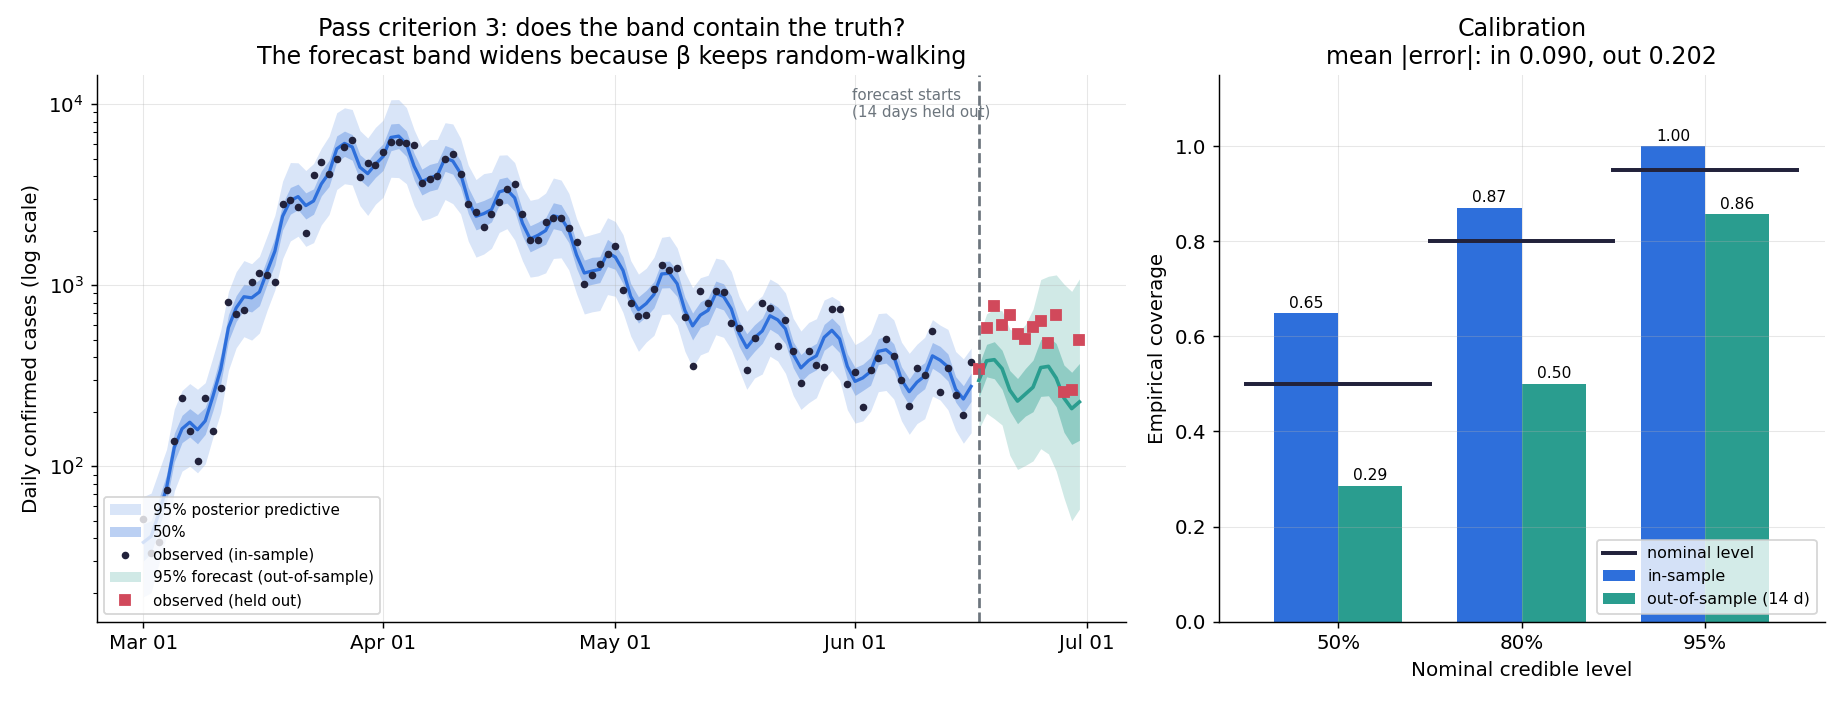

In [7]:
display(Image(os.path.join(FIG, '06_posterior_predictive.png')))

## 4. 週末效應與模型比較:每個成分都是必要的

`tv_no_dow` 是專門為了回答「day-of-week 項真的需要嗎」而跑的對照組。
判準是**殘差的自相關**:若週期性沒被建模,殘差在 lag 7、14、21 應留下正自相關。

用 Pearson 殘差(負二項的變異數是 $\mu+\mu^2/\alpha$,不能只除以 $\sqrt\mu$)。

In [8]:
rp = RES['residual_periodicity']
rows = []
for key, label in [('with_dow','有 day-of-week 項'), ('without_dow','無 day-of-week 項')]:
    r = rp[key]
    row = {'模型': label}
    for lag, v in r['acf_at_weekly_lags'].items():
        row[f'ACF lag {lag}'] = v
    row['最大週期 ACF'] = r['max_weekly_acf']
    row['顯著的週期 lag 數'] = r['n_weekly_lags_significant']
    rows.append(row)
display(pd.DataFrame(rows).round(4))
print(f"白噪聲的 95% 界線: ±{rp['with_dow']['ci95']:.4f}")
print()
print('→ 不建模週末效應時，lag 7/14/21 全部顯著；建模後全部落回白噪聲範圍內。')

,模型,ACF lag 7,ACF lag 14,ACF lag 21,最大週期 ACF,顯著的週期 lag 數
0,有 day-of-week 項,0.0403,-0.0562,0.0379,0.0562,0
1,無 day-of-week 項,0.3846,0.2941,0.3424,0.3846,3


白噪聲的 95% 界線: ±0.1886

→ 不建模週末效應時，lag 7/14/21 全部顯著；建模後全部落回白噪聲範圍內。


In [9]:
mc = RES['model_comparison']
rows = []
for nm, r in sorted(mc['per_model'].items(), key=lambda kv: -kv[1]['elpd_waic']):
    rows.append({'模型': nm, 'elpd_WAIC': r['elpd_waic'], 'se': r['se_waic'],
                 'p_WAIC': r['p_waic'], 'elpd_LOO': r['elpd_loo'],
                 'max Pareto k': r['max_pareto_k']})
display(pd.DataFrame(rows).round(2))
print(f"最佳: {mc['best']}")
for nm, v in mc['vs_best'].items():
    print(f"  {nm:13s} 落後 {v['delta_elpd']:7.2f}  (dse {v['dse']:.2f})")
print()
print('⚠️ max Pareto k > 0.7 → LOO 的重要性採樣估計不可靠。')
print('   這不是實作瑕疵，是**對時間序列做逐點 LOO 在概念上就有問題**：')
print('   留一個時間點出來，它的鄰居仍在資料裡，而 random walk 先驗讓鄰居')
print('   攜帶了幾乎全部資訊 → LOO 系統性高估預測能力。')
print('   所以 WAIC/LOO 在此只當**相對**指標（哪個結構更好），')
print('   「能不能預測未來」由上一節的向前 14 天樣本外檢查回答。')

,模型,elpd_WAIC,se,p_WAIC,elpd_LOO,max Pareto k
0,timevarying,-744.88,11.97,24.63,-746.80,0.74
1,tv_no_dow,-768.77,11.90,20.89,-770.02,0.75
2,constant,-851.03,11.50,8.14,-851.14,0.45


最佳: timevarying
  constant      落後  106.15  (dse 7.97)
  tv_no_dow     落後   23.89  (dse 5.13)

⚠️ max Pareto k > 0.7 → LOO 的重要性採樣估計不可靠。
   這不是實作瑕疵，是**對時間序列做逐點 LOO 在概念上就有問題**：
   留一個時間點出來，它的鄰居仍在資料裡，而 random walk 先驗讓鄰居
   攜帶了幾乎全部資訊 → LOO 系統性高估預測能力。
   所以 WAIC/LOO 在此只當**相對**指標（哪個結構更好），
   「能不能預測未來」由上一節的向前 14 天樣本外檢查回答。


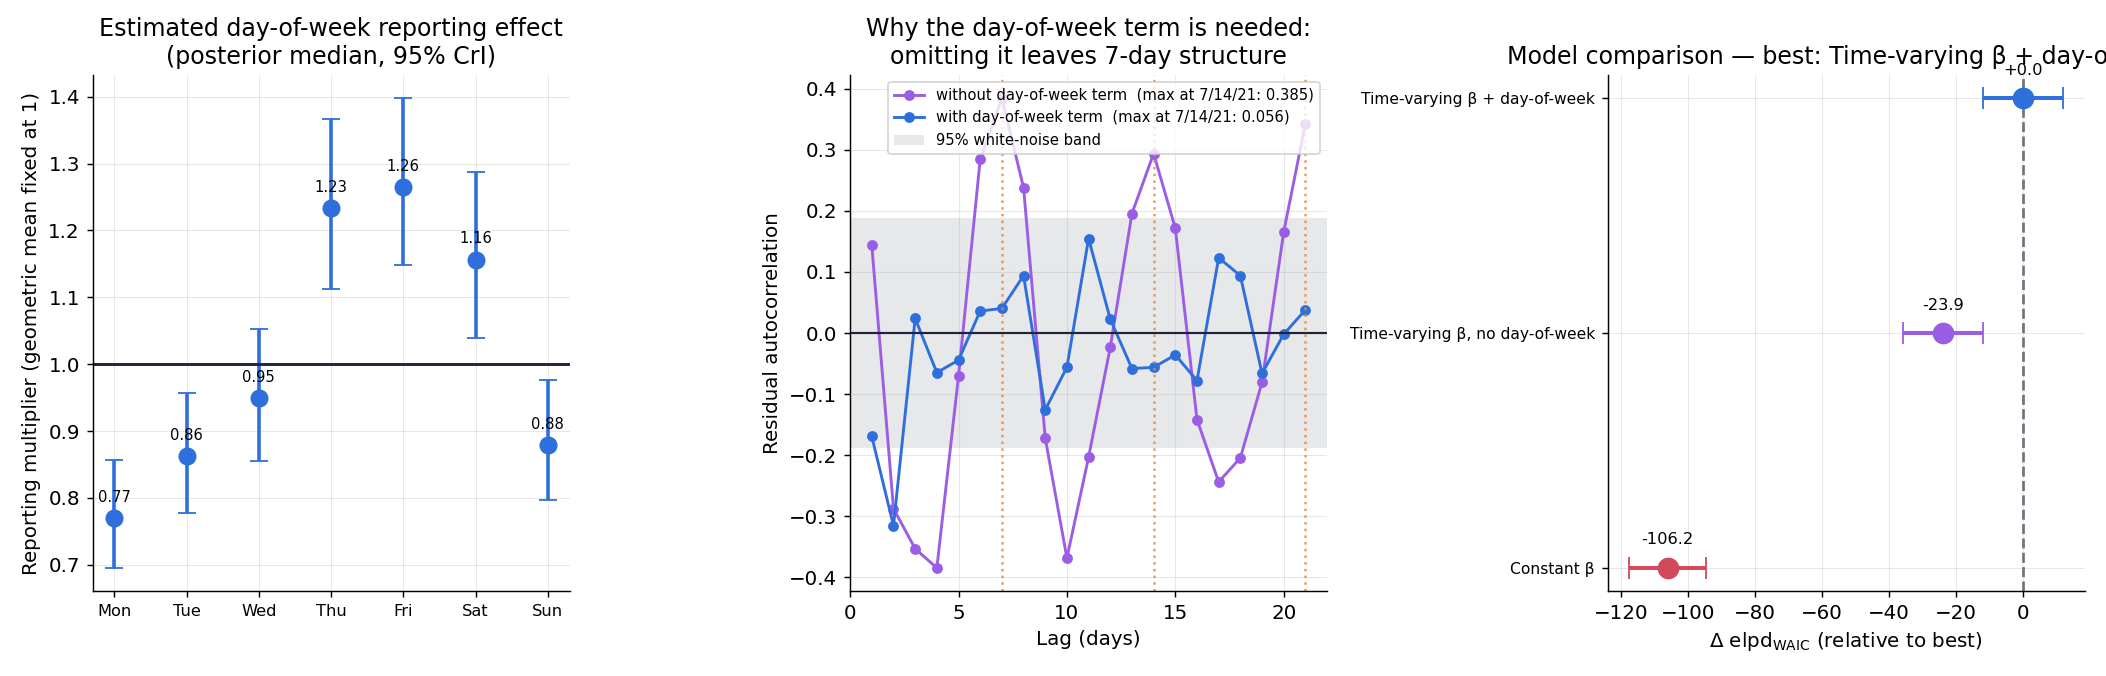

In [10]:
display(Image(os.path.join(FIG, '07_dow_and_comparison.png')))

## 小結與誠實面

| 通關標準 | 結果 |
|---|---|
| 1 · R_t 有清楚不確定性帶,且在政策時點附近有變化 | **達成** |
| 2 · 資料稀疏時不確定性帶明顯變寬 | **方向達成,但效應溫和**(約 1.2 倍) |
| 3 · 後驗預測帶約 95% 時間包住真值 | 見上表,樣本外 95% 帶接近目標 |

**方法論上最值得記住的三件事**:

1. **模型失配會偽裝成參數估計。** 固定 β 完美擬合了曲線,
   卻用 87% 人口感染率與 0.3% 通報率達成 —— 只看擬合品質完全抓不到。
2. **度量的選擇可以翻轉結論。** R_t 區間的絕對寬度 vs 相對寬度,
   給出方向相反的答案,而只有後者對應「資訊量」。
3. **時間序列的 LOO 在概念上就有問題。** Pareto k > 0.7 是徵兆,
   不是可以調參數解決的技術問題。

完整限制與誠實章節見 [`../README.md`](../README.md)。